In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.set()

In [2]:
#The main URL for all FPL data
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'

#Fetches the data and parse the JSON
response = requests.get(url)
data = response.json()

In [22]:
# Extracting the list of players
players_data = data['elements']

# Converts the data into a pandas DataFrame
df = pd.DataFrame(players_data)

print(df.shape)

(840, 105)


## Goalkeeper Model


In [23]:
gf_df = df[df['element_type'] == 1][[
    'id', 
    'web_name', 
    'starts', 
    'saves_per_90', 
    'expected_goals_conceded_per_90', 
    'clean_sheets_per_90', 
    'total_points'
]].copy()

# Convert all modeling columns to numeric to avoid string/object issues
numeric_cols = ['starts', 'saves_per_90', 'expected_goals_conceded_per_90', 'clean_sheets_per_90', 'total_points']
for col in numeric_cols:
    gf_df[col] = pd.to_numeric(gf_df[col])

gf_df.head(40)

,id,web_name,starts,saves_per_90,expected_goals_conceded_per_90,clean_sheets_per_90,total_points
0,1,Raya,37,1.62,0.74,0.51,162
1,2,Arrizabalaga,0,0.00,0.00,0.00,0
2,3,Hein,0,0.00,0.00,0.00,0
3,4,Setford,0,0.00,0.00,0.00,0
36,32,Martinez,32,3.02,1.36,0.22,120
37,33,M.Bizot,5,3.09,1.76,0.18,14
38,34,Gauci,0,0.00,0.00,0.00,0
39,35,Marschall,0,0.00,0.00,0.00,0
71,688,Wright,0,0.00,0.00,0.00,0
75,703,Proctor,0,0.00,0.00,0.00,0


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

gf_df_starters = gf_df[gf_df['starts'] >= 20].copy()

X_starters = gf_df_starters[['starts', 'saves_per_90', 'expected_goals_conceded_per_90', 'clean_sheets_per_90']]
y_starters = gf_df_starters['total_points']

X_train, X_test, y_train, y_test = train_test_split(X_starters, y_starters, test_size=0.2, random_state=42)

starter_model = LinearRegression()
starter_model.fit(X_train, y_train)

y_train_pred = starter_model.predict(X_train)
y_test_pred = starter_model.predict(X_test)

print("\n")
print(f"Total Starting Keepers Analysed: {len(gf_df_starters)}")
print(f"Train Set R2 Score:             {r2_score(y_train, y_train_pred):.4f}")
print(f"Test Set R2 Score:              {r2_score(y_test, y_test_pred):.4f}")
print(f"Mean Absolute Error (MAE):      {mean_absolute_error(y_test, y_test_pred):.2f} points")
print("\n")

#Verify our model 
def verify_starter(name):
    player_row = gf_df_starters[gf_df_starters['web_name'].str.lower() == name.lower()]
    if player_row.empty:
        print(f"Keeper '{name}' not found or has fewer than 20 starts.")
        return
    
    actual_pts = player_row['total_points'].values[0]
    features = player_row[['starts', 'saves_per_90', 'expected_goals_conceded_per_90', 'clean_sheets_per_90']]
    predicted_pts = starter_model.predict(features)[0]
    
    print(f"Verification: {player_row['web_name'].values[0]}")
    print(f"Actual Season Points:    {actual_pts}")
    print(f"Predicted Season Points: {predicted_pts:.1f}")
    print(f"Difference (Error):      {actual_pts - predicted_pts:+.1f}\n")


verify_starter("Raya")




Total Starting Keepers Analysed: 20
Train Set R2 Score:             0.9558
Test Set R2 Score:              0.8890
Mean Absolute Error (MAE):      8.42 points


Verification: Raya
Actual Season Points:    162
Predicted Season Points: 151.3
Difference (Error):      +10.7



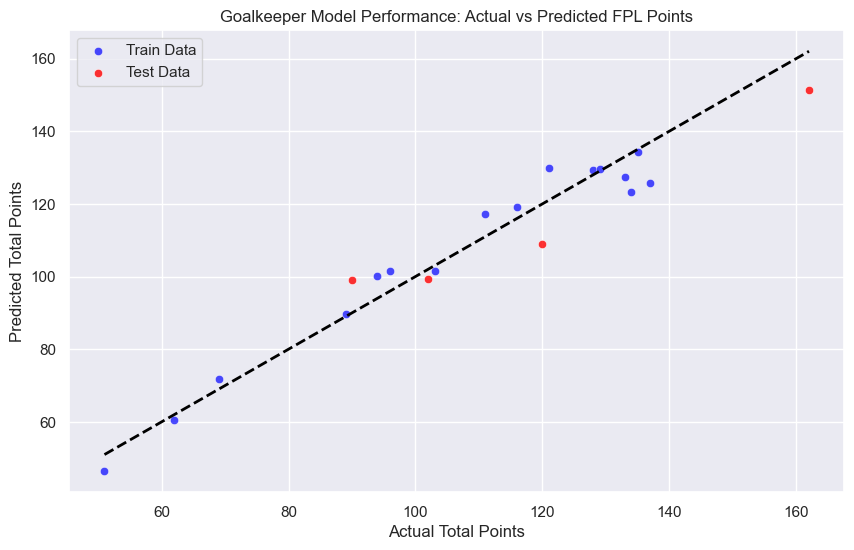

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_train, y=y_train_pred, color='blue', alpha=0.7, label='Train Data')
sns.scatterplot(x=y_test, y=y_test_pred, color='red', alpha=0.8, label='Test Data')

# Add a perfect prediction line diagonal
plt.plot([y_starters.min(), y_starters.max()], [y_starters.min(), y_starters.max()], color='black', lw=2, linestyle='--')

plt.title('Goalkeeper Model Performance: Actual vs Predicted FPL Points')
plt.xlabel('Actual Total Points')
plt.ylabel('Predicted Total Points')
plt.legend()
plt.show()

## Defender Model

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df_def = df[df['element_type'] == 2].copy()

numeric_cols = [
    'starts',
    'expected_goals_per_90',
    'expected_assists_per_90',
    'expected_goals_conceded_per_90',
    'clean_sheets_per_90',
    'total_points'
]

for col in numeric_cols:
    df_def[col] = pd.to_numeric(df_def[col])

# Creating a custom attacking measure 
df_def['expected_attacking_pts_per_90'] = (
    (df_def['expected_goals_per_90'] * 6) +
    (df_def['expected_assists_per_90'] * 3)
)

df_def_starters = df_def[df_def['starts'] >= 10].copy()

features_list = [
    'starts',
    'expected_attacking_pts_per_90',
    'expected_goals_conceded_per_90',
    'clean_sheets_per_90'
]

X_def = df_def_starters[features_list]
y_def = df_def_starters['total_points']


X_train, X_test, y_train, y_test = train_test_split(
    X_def,
    y_def,
    test_size=0.2,
    random_state=42
)

def_model = LinearRegression()
def_model.fit(X_train, y_train)


y_train_pred = def_model.predict(X_train)
y_test_pred = def_model.predict(X_test)


print(f"Total Active Defenders Analysed: {len(df_def_starters)}")
print(f"Train Set R2 Score:             {r2_score(y_train, y_train_pred):.4f}")
print(f"Test Set R2 Score:              {r2_score(y_test, y_test_pred):.4f}")
print(f"Mean Absolute Error (MAE):      {mean_absolute_error(y_test, y_test_pred):.2f} points")


def verify_defender(name):
    
    player_row = df_def_starters[
        df_def_starters['web_name'].str.lower() == name.lower()
    ]
    
    if player_row.empty:
        print(f"Defender '{name}' not found or has fewer than 10 starts.")
        return
    
    actual_pts = player_row['total_points'].values[0]
    
    features = player_row[features_list]
    
    predicted_pts = def_model.predict(features)[0]
    
    print(f"Verification: {player_row['web_name'].values[0]}")
    print(f"Actual Season Points:    {actual_pts}")
    print(f"Predicted Season Points: {predicted_pts:.1f}")
    print(f"Difference (Error):      {actual_pts - predicted_pts:+.1f}\n")


print("RUNNING BIG 6 VERIFICATION CHECKS \n")

verify_defender("Gabriel")
verify_defender("Gvardiol")
verify_defender("Frimpong")
verify_defender("Calafiori")
verify_defender("Dalot")
verify_defender("Chalobah")

Total Active Defenders Analysed: 126
Train Set R2 Score:             0.8477
Test Set R2 Score:              0.8820
Mean Absolute Error (MAE):      10.20 points
RUNNING BIG 6 VERIFICATION CHECKS 

Verification: Gabriel
Actual Season Points:    208
Predicted Season Points: 150.5
Difference (Error):      +57.5

Verification: Gvardiol
Actual Season Points:    78
Predicted Season Points: 89.6
Difference (Error):      -11.6

Verification: Frimpong
Actual Season Points:    62
Predicted Season Points: 68.2
Difference (Error):      -6.2

Verification: Calafiori
Actual Season Points:    108
Predicted Season Points: 141.3
Difference (Error):      -33.3

Verification: Dalot
Actual Season Points:    111
Predicted Season Points: 109.5
Difference (Error):      +1.5

Verification: Chalobah
Actual Season Points:    135
Predicted Season Points: 113.3
Difference (Error):      +21.7



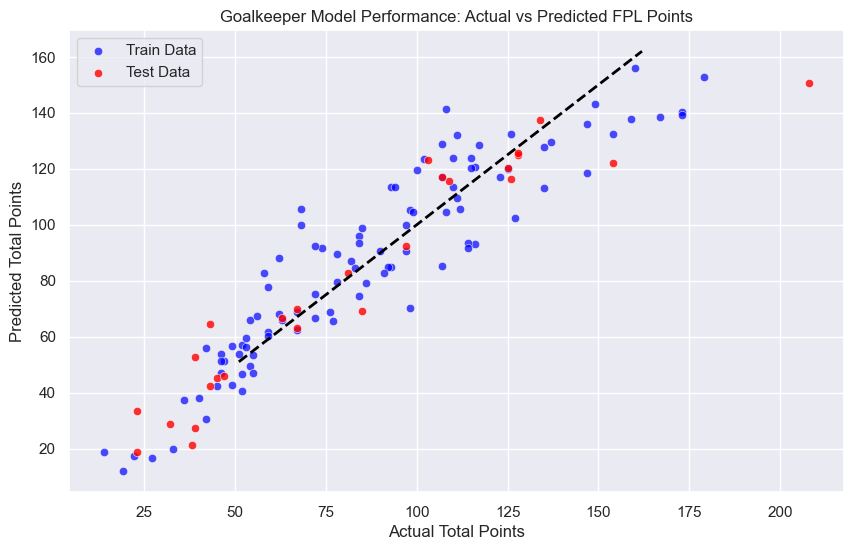

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_train, y=y_train_pred, color='blue', alpha=0.7, label='Train Data')
sns.scatterplot(x=y_test, y=y_test_pred, color='red', alpha=0.8, label='Test Data')

plt.plot([y_starters.min(), y_starters.max()], [y_starters.min(), y_starters.max()], color='black', lw=2, linestyle='--')

plt.title('Goalkeeper Model Performance: Actual vs Predicted FPL Points')
plt.xlabel('Actual Total Points')
plt.ylabel('Predicted Total Points')
plt.legend()
plt.show()

In [28]:
verify_defender("Cucurella")

Verification: Cucurella
Actual Season Points:    103
Predicted Season Points: 123.2
Difference (Error):      -20.2



## Attacker and Midfielder Model

In [29]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

critical_cols = [
    'web_name',
    'element_type',
    'starts',
    'expected_goals_per_90',
    'expected_assists_per_90',
    'clean_sheets_per_90',
    'total_points',
    'direct_freekicks_order'
]

# Filter attackers and select columns
df_attackers = df[df['element_type'].isin([3, 4])][critical_cols].copy()


for col in critical_cols[1:]:
    df_attackers[col] = pd.to_numeric(df_attackers[col], errors='coerce')

# Remove missing values
df_attackers.dropna(subset=['total_points', 'starts'], inplace=True)

df_attackers_starters = df_attackers[df_attackers['starts'] >= 10].copy()

# Feature engineering
df_attackers_starters['is_midfielder'] = (
    df_attackers_starters['element_type'] == 3
).astype(int)

df_attackers_starters['xG_interaction'] = (
    df_attackers_starters['expected_goals_per_90'] *
    df_attackers_starters['is_midfielder']
)

df_attackers_starters['CS_interaction'] = (
    df_attackers_starters['clean_sheets_per_90'] *
    df_attackers_starters['is_midfielder']
)

df_attackers_starters['is_freekick_taker'] = (
    df_attackers_starters['direct_freekicks_order'] == 1
).astype(int)

features_list = [
    'starts',
    'expected_goals_per_90',
    'expected_assists_per_90',
    'is_midfielder',
    'xG_interaction',
    'CS_interaction',
    'is_freekick_taker'
]

X_att = df_attackers_starters[features_list].to_numpy()
y_att = df_attackers_starters['total_points'].to_numpy()

# Cross-validation simulation
num_iterations = 1000

train_r2_scores = np.empty(num_iterations)
test_r2_scores = np.empty(num_iterations)
mae_scores = np.empty(num_iterations)

model = LinearRegression()

for i in range(num_iterations):
    X_train, X_test, y_train, y_test = train_test_split(
        X_att,
        y_att,
        test_size=0.2
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2_scores[i] = r2_score(y_train, y_train_pred)
    test_r2_scores[i] = r2_score(y_test, y_test_pred)
    mae_scores[i] = mean_absolute_error(y_test, y_test_pred)

print("Model Metrics")
print("\n")
print(f"Average Train R2: {np.mean(train_r2_scores):.4f}")
print(f"Average Test R2:  {np.mean(test_r2_scores):.4f}")
print(f"Average MAE:      {np.mean(mae_scores):.2f}")

# Final model
final_attack_model = LinearRegression()
final_attack_model.fit(X_att, y_att)

print("\nFeature Coefficients")
print("\n")

for feat, coef in zip(features_list, final_attack_model.coef_):
    print(f"{feat:<25}: {coef:+.2f}")

Model Metrics


Average Train R2: 0.8479
Average Test R2:  0.8070
Average MAE:      12.75

Feature Coefficients


starts                   : +3.94
expected_goals_per_90    : +149.98
expected_assists_per_90  : +92.70
is_midfielder            : +25.86
xG_interaction           : -75.09
CS_interaction           : +13.74
is_freekick_taker        : +16.78


In [35]:
import requests
import json
import pandas as pd

layer_1_config = {}

# GOALKEEPERS

layer_1_config["goalkeepers"] = {
    "intercept": round(starter_model.intercept_, 4),
    "weights": {
        feature: round(weight, 4)
        for feature, weight in zip(
            X_starters.columns,
            starter_model.coef_
        )
    }
}

print("Goalkeeper model added")

# DEFENDERS

layer_1_config["defenders"] = {
    "intercept": round(def_model.intercept_, 4),
    "weights": {
        feature: round(weight, 4)
        for feature, weight in zip(
            X_def.columns,
            def_model.coef_
        )
    }
}

print("Defender model added")

# ATTACKERS

layer_1_config["attackers"] = {
    "intercept": round(final_attack_model.intercept_, 4),
    "weights": {
        feature: round(weight, 4)
        for feature, weight in zip(
            features_list,
            final_attack_model.coef_
        )
    }
}

print("Attacker model added")

# EXPORT JSON

with open("layer1_weights.json", "w") as f:
    json.dump(layer_1_config, f, indent=4)

print("\nlayer1_weights.json created successfully")
print(json.dumps(layer_1_config, indent=2))

Goalkeeper model added
Defender model added
Attacker model added

layer1_weights.json created successfully
{
  "goalkeepers": {
    "intercept": -38.5736,
    "weights": {
      "starts": 3.4754,
      "saves_per_90": 13.4662,
      "expected_goals_conceded_per_90": -20.6661,
      "clean_sheets_per_90": 107.3402
    }
  },
  "defenders": {
    "intercept": -34.6495,
    "weights": {
      "starts": 3.4833,
      "expected_attacking_pts_per_90": 27.1788,
      "expected_goals_conceded_per_90": 0.6103,
      "clean_sheets_per_90": 98.3504
    }
  },
  "attackers": {
    "intercept": -47.7048,
    "weights": {
      "starts": 3.9384,
      "expected_goals_per_90": 149.9752,
      "expected_assists_per_90": 92.7007,
      "is_midfielder": 25.8639,
      "xG_interaction": -75.0868,
      "CS_interaction": 13.7391,
      "is_freekick_taker": 16.7826
    }
  }
}


In [43]:
import requests
import json
import numpy as np
import pandas as pd
import pulp 

with open('layer1_weights.json', 'r') as f: layer1 = json.load(f)
bootstrap_data = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/').json()
df_elements, df_teams = pd.DataFrame(bootstrap_data['elements']), pd.DataFrame(bootstrap_data['teams'])
team_map = {team['id']: team['short_name'] for team in bootstrap_data['teams']}

# ECOSYSTEM & FIXTURES 
league_att_avg = np.mean([t['strength_attack_home'] + t['strength_attack_away'] for t in bootstrap_data['teams']])
league_def_avg = np.mean([t['strength_defence_home'] + t['strength_defence_away'] for t in bootstrap_data['teams']])
team_strengths = {t['id']: {'att_eco': (t['strength_attack_home'] + t['strength_attack_away']) / league_att_avg, 'def_eco': (t['strength_defence_home'] + t['strength_defence_away']) / league_def_avg, 'att_h': t['strength_attack_home'], 'att_a': t['strength_attack_away'], 'def_h': t['strength_defence_home'], 'def_a': t['strength_defence_away']} for t in bootstrap_data['teams']}

fixtures_data = requests.get('https://fantasy.premierleague.com/api/fixtures/?future=1').json()
df_fixtures = pd.DataFrame(fixtures_data)

upcoming_mismatch, upcoming_opp = {}, {}
for team_id in df_teams['id']:
    team_games = df_fixtures[(df_fixtures['team_h'] == team_id) | (df_fixtures['team_a'] == team_id)].head(1)
    if not team_games.empty:
        game = team_games.iloc[0]
        opp_id = game['team_a'] if game['team_h'] == team_id else game['team_h']
        opp_str = f"vs {team_map[opp_id]} ({'H' if game['team_h'] == team_id else 'A'})"
        att_miss = team_strengths[team_id]['att_h']/team_strengths[opp_id]['def_a'] if game['team_h']==team_id else team_strengths[team_id]['att_a']/team_strengths[opp_id]['def_h']
        def_miss = team_strengths[team_id]['def_h']/team_strengths[opp_id]['att_a'] if game['team_h']==team_id else team_strengths[team_id]['def_a']/team_strengths[opp_id]['att_h']
    else: opp_str, att_miss, def_miss = "No Fixture", 1.0, 1.0
    upcoming_mismatch[team_id] = {'att': att_miss, 'def': def_miss}
    upcoming_opp[team_id] = opp_str

# NORMALIZED PROJECTIONS & SYNERGY
projected_players = []
for _, p in df_elements.iterrows():
    if p['starts'] < 15 or p['status'] != 'a': continue 
    
    pos, team_id = p['element_type'], p['team']
    matchup = upcoming_opp.get(team_id, "Unknown")
    ownership, form_pts = float(p['selected_by_percent']), float(p['form'])
    
    if ownership < 4.0 and (p['transfers_in_event'] - p['transfers_out_event']) < 10000: continue
    
    # Base Stats Calculation
    base_season_pts = 0
    if pos == 1: 
        w = layer1['goalkeepers']['weights']
        base_season_pts = layer1['goalkeepers']['intercept'] + (p['starts'] * w['starts']) + (float(p['saves_per_90']) * w['saves_per_90']) + (float(p['expected_goals_conceded_per_90']) * w['expected_goals_conceded_per_90']) + (float(p['clean_sheets_per_90']) * w['clean_sheets_per_90'])
    elif pos == 2: 
        w = layer1['defenders']['weights']
        base_season_pts = layer1['defenders']['intercept'] + (p['starts'] * w['starts']) + (((float(p['expected_goals_per_90']) * 6) + (float(p['expected_assists_per_90']) * 3)) * w['expected_attacking_pts_per_90']) + (float(p['expected_goals_conceded_per_90']) * w['expected_goals_conceded_per_90']) + (float(p['clean_sheets_per_90']) * w['clean_sheets_per_90'])
    elif pos in [3, 4]: 
        w = layer1['attackers']['weights']
        is_mid = 1 if pos == 3 else 0
        base_season_pts = layer1['attackers']['intercept'] + (p['starts'] * w['starts']) + (float(p['expected_goals_per_90']) * w['expected_goals_per_90']) + (float(p['expected_assists_per_90']) * w['expected_assists_per_90']) + (is_mid * w['is_midfielder']) + ((float(p['expected_goals_per_90']) * is_mid) * w['xG_interaction']) + ((float(p['clean_sheets_per_90']) * is_mid) * w['CS_interaction']) + ((1 if p['direct_freekicks_order'] == 1 else 0) * w['is_freekick_taker'])

    # DEFLATION & NORMALIZATION: Soften the multipliers so points don't inflate
    eco_mult = team_strengths[team_id]['def_eco'] if pos in [1, 2] else team_strengths[team_id]['att_eco']
    fdr_mult = upcoming_mismatch[team_id]['def'] if pos in [1, 2] else upcoming_mismatch[team_id]['att']
    
    # Blend multipliers softly
    safe_multiplier = (1.0 + eco_mult + fdr_mult) / 3.0
    
    # TEAM SYNERGY
    synergy_bonus = 0.0
    if pos in [1, 2] and eco_mult > 1.15: synergy_bonus = 0.4
    if pos in [3, 4] and eco_mult > 1.15: synergy_bonus = 0.5
    
    proj_pts = (base_season_pts / 38.0) * safe_multiplier * min(1.0, (p['minutes'] / max(1, p['starts'])) / 85.0)
    proj_pts = (proj_pts * 0.6) + (form_pts * 0.4) + synergy_bonus # Final realistic blend
    
    projected_players.append({'id': p['id'], 'name': p['web_name'], 'team_id': team_id, 'matchup': matchup, 'pos': pos, 'cost': p['now_cost'], 'ownership': ownership, 'proj_pts': round(proj_pts, 2)})

df_proj = pd.DataFrame(projected_players)

# STARTING 11 vs BENCH 4
prob = pulp.LpProblem("FPL_Starting11_Optimizer", pulp.LpMaximize)

squad_vars = pulp.LpVariable.dicts("Squad", df_proj['id'], cat='Binary')
start_vars = pulp.LpVariable.dicts("Starter", df_proj['id'], cat='Binary')

#ONLY MAXIMIZE THE STARTING 11's POINTS
prob += pulp.lpSum([df_proj[df_proj['id'] == i]['proj_pts'].values[0] * start_vars[i] for i in df_proj['id']])

# A starter MUST be in the squad
for i in df_proj['id']: prob += start_vars[i] <= squad_vars[i]

# Budget & Total Players Constraints 
prob += pulp.lpSum([df_proj[df_proj['id'] == i]['cost'].values[0] * squad_vars[i] for i in df_proj['id']]) <= 1000
prob += pulp.lpSum([squad_vars[i] for i in df_proj['id']]) == 15
prob += pulp.lpSum([squad_vars[i] for i in df_proj[df_proj['pos'] == 1]['id']]) == 2
prob += pulp.lpSum([squad_vars[i] for i in df_proj[df_proj['pos'] == 2]['id']]) == 5
prob += pulp.lpSum([squad_vars[i] for i in df_proj[df_proj['pos'] == 3]['id']]) == 5
prob += pulp.lpSum([squad_vars[i] for i in df_proj[df_proj['pos'] == 4]['id']]) == 3
for t in df_proj['team_id'].unique(): prob += pulp.lpSum([squad_vars[i] for i in df_proj[df_proj['team_id'] == t]['id']]) <= 3

#Starting 11 Formation Rules (The AI picks the best formation)
prob += pulp.lpSum([start_vars[i] for i in df_proj['id']]) == 11
prob += pulp.lpSum([start_vars[i] for i in df_proj[df_proj['pos'] == 1]['id']]) == 1 
prob += pulp.lpSum([start_vars[i] for i in df_proj[df_proj['pos'] == 2]['id']]) >= 3 
prob += pulp.lpSum([start_vars[i] for i in df_proj[df_proj['pos'] == 3]['id']]) >= 2 
prob += pulp.lpSum([start_vars[i] for i in df_proj[df_proj['pos'] == 4]['id']]) >= 1 

prob += pulp.lpSum([squad_vars[i] for i in df_proj[(df_proj['cost'] >= 95) & (df_proj['pos'].isin([3, 4]))]['id']]) >= 2
prob += pulp.lpSum([squad_vars[i] for i in df_proj[df_proj['ownership'] >= 15.0]['id']]) >= 6

prob.solve(pulp.PULP_CBC_CMD(msg=0))

#PRINT THE STARTING XI vs BENCH
print(" OPTIMIZED(STARTING 11 + BENCH) \n")
starters, bench, total_cost, total_xi_pts = [], [], 0, 0

for i in df_proj['id']:
    if squad_vars[i].varValue == 1.0:
        p_data = df_proj[df_proj['id'] == i].iloc[0]
        total_cost += p_data['cost']
        if start_vars[i].varValue == 1.0:
            starters.append(p_data)
            total_xi_pts += p_data['proj_pts']
        else:
            bench.append(p_data)

pos_map = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}
print("STARTING XI:")
for _, p in pd.DataFrame(starters).sort_values(by=['pos', 'proj_pts'], ascending=[True, False]).iterrows():
    print(f"[{pos_map[p['pos']]}] {p['name']:<15} | {p['matchup']:<12} | £{p['cost']/10:>4.1f}m | Proj: {p['proj_pts']:.1f}")

print("\n BENCH :")
for _, p in pd.DataFrame(bench).sort_values(by=['pos']).iterrows():
    print(f"[{pos_map[p['pos']]}] {p['name']:<15} | {p['matchup']:<12} | £{p['cost']/10:>4.1f}m | Proj: {p['proj_pts']:.1f}")

print(f"\n Total Squad Cost:  £{total_cost/10:.1f}m / £100.0m")
print(f" STARTING XI Proj Pts: {total_xi_pts:.1f} pts")

 OPTIMIZED(STARTING 11 + BENCH) 

STARTING XI:
[GK] Raya            | vs CRY (A)   | £ 6.2m | Proj: 5.7
[DEF] Gabriel         | vs CRY (A)   | £ 7.3m | Proj: 5.7
[DEF] Senesi          | vs NFO (A)   | £ 5.2m | Proj: 5.3
[DEF] Guéhi           | vs AVL (H)   | £ 5.1m | Proj: 4.8
[DEF] Truffert        | vs NFO (A)   | £ 4.7m | Proj: 4.6
[MID] Anderson        | vs BOU (H)   | £ 5.6m | Proj: 5.6
[MID] Saka            | vs CRY (A)   | £10.0m | Proj: 5.3
[MID] Enzo            | vs SUN (A)   | £ 6.4m | Proj: 5.1
[MID] Gibbs-White     | vs BOU (H)   | £ 7.5m | Proj: 4.9
[FWD] Haaland         | vs AVL (H)   | £14.7m | Proj: 6.1
[FWD] Watkins         | vs MCI (A)   | £ 8.7m | Proj: 5.1

 BENCH :
[GK] Dúbravka        | vs WOL (H)   | £ 4.0m | Proj: 2.1
[DEF] Estève          | vs WOL (H)   | £ 3.8m | Proj: 2.7
[MID] Anthony         | vs WOL (H)   | £ 5.0m | Proj: 3.4
[FWD] Kroupi.Jr       | vs NFO (A)   | £ 4.6m | Proj: 4.0

 Total Squad Cost:  £98.8m / £100.0m
 STARTING XI Proj Pts: 58.1 pts
